In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier, XGBRegressor
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('insurance_clean.csv')
df_unclean = pd.read_csv('insurance_data.csv')
print(len(df))
print(len(df_unclean))

858
1000


In [3]:
df = df.drop(columns = ['Term_Length'])
df = df.drop(columns = ['median_income'])
df = df.drop(columns = ['consumer_sentiment'])
df = df.drop(columns = ['unemployment'])
df = df.drop(columns = ['Lapse_Rate'])
df = df.drop(columns = ['treasury_spread'])
df = df.drop(columns = ['Issue_Year'])

In [4]:
y = df['Lapsed']
X = df.drop(columns =['Lapsed'])
print(X.shape)
print(y.shape)
print(X.columns.tolist())

(858, 13)
(858,)
['Birth_Year', 'Face_Amount', 'Annual_Premium', 'Issued_Age', 'BMI', 'Number_of_Beneficiaries', 'Mortality_Rate', 'Is_Smoker', 'Is_Female', 'Payment_Method_Check', 'Payment_Method_Credit Card', 'Payment_Method_Wire', 'Premium_ratio']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)

In [6]:
xgb_model = XGBClassifier(n_estimators = 500,
                      max_depth = 6,
                      learning_rate = 0.1,
                      random_state = 40)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [7]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.9419


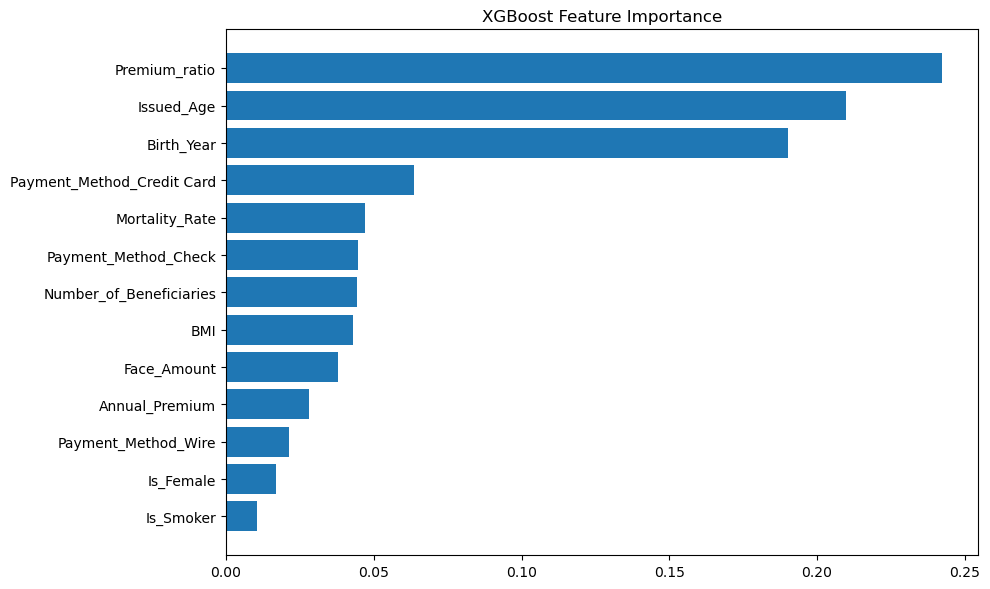

In [8]:
plt.figure(figsize=(10, 6))
importance = xgb_model.feature_importances_
sorted_idx = np.argsort(importance)
plt.barh(X.columns[sorted_idx], importance[sorted_idx])
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

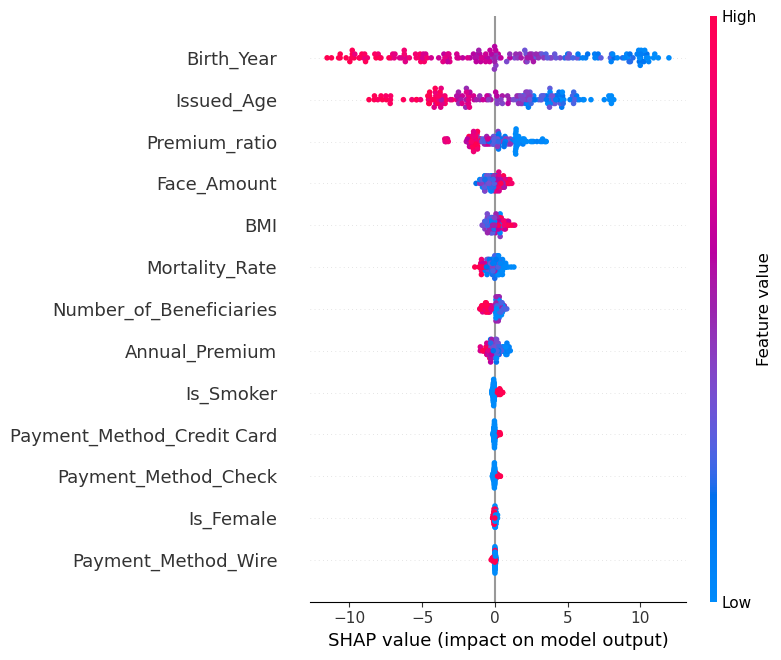

In [9]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    random_state=40
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=500, random_state=40)

In [11]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [12]:
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

Accuracy: 0.6977


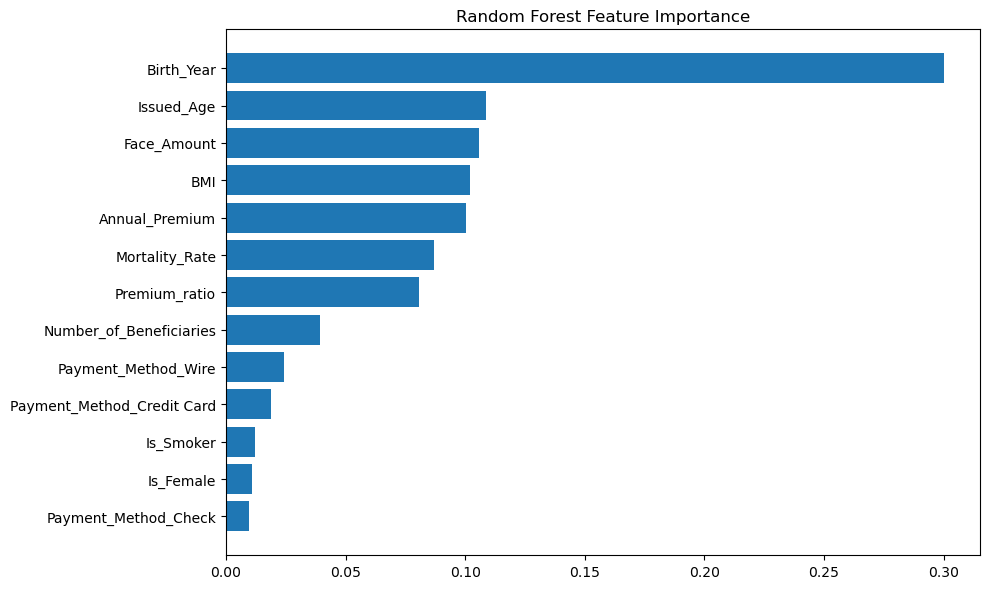

In [13]:
plt.figure(figsize=(10, 6))
rf_importance = rf_model.feature_importances_
sorted_idx = np.argsort(rf_importance)
plt.barh(X.columns[sorted_idx], rf_importance[sorted_idx])
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

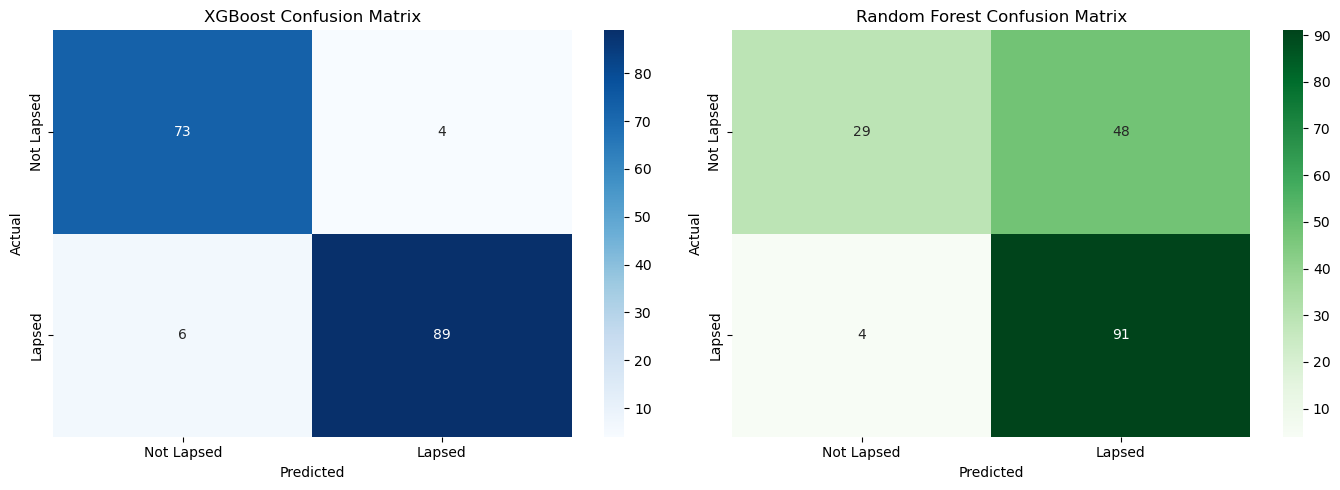

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Lapsed', 'Lapsed'],
            yticklabels=['Not Lapsed', 'Lapsed'])
axes[0].set_title('XGBoost Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Lapsed', 'Lapsed'],
            yticklabels=['Not Lapsed', 'Lapsed'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import cross_val_predict

xgb_p_lapse = cross_val_predict(
    XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1, random_state=40),
    X, y, cv=5, method='predict_proba'
)[:, 1]

In [16]:
df_xgb = X.copy()
df_xgb['p_lapse'] = xgb_p_lapse

In [17]:
df_xgb['Issue_Year'] = df_xgb['Birth_Year'] + df_xgb['Issued_Age']
df_xgb['Policy_Year'] = 2025 - df_xgb['Issue_Year']
df_xgb['Remaining_Term'] = 20 - df_xgb['Policy_Year']

In [18]:
print(df_xgb['Remaining_Term'].value_counts().sort_index())

Remaining_Term
-5    86
-4    97
-3    85
-2    70
-1    79
 0    80
 1    83
 2    74
 3    66
 4    81
 5    57
Name: count, dtype: int64


In [19]:
active = df_xgb[df_xgb['Remaining_Term'] > 0].copy()
print(f"Active policies: {len(active)}")

Active policies: 361


In [20]:
def pv_xgboost(row, discount_rate=0.05, lapse_cost_pct=0.02):
    """
    lapse_cost_pct: fraction of Face_Amount lost per lapse event
    discount_rate: future cash flow in terms of todays value
    this is the estimated portfolio value/revenue by XGboost

    income = premiums collected - death payout(estimated) - lapse cost
    cash_flow = income/1+discount rate
    """
    pv = 0
    in_force = 1.0   #proportion of the policy that is still active, or easily, the probability of a person to stay
    remaining = int(row['Remaining_Term'])
    
    for t in range(1, remaining + 1):
        premium_in = row['Annual_Premium'] * in_force
        death_payout = row['Face_Amount'] * row['Mortality_Rate'] * in_force
        lapse_cost = row['Face_Amount'] * lapse_cost_pct * in_force * row['p_lapse']
        
        net_cashflow = premium_in - death_payout - lapse_cost
        pv += net_cashflow / (1 + discount_rate) ** t
        
        in_force *= (1 - row['Mortality_Rate']) * (1 - row['p_lapse']) #update inforce
    return pv

active['PV_xgboost'] = active.apply(pv_xgboost, axis=1)

In [21]:
print(f"Total: ${active['PV_xgboost'].sum():,.2f}")

Total: $-782,455.46


In [22]:
print(active[['Annual_Premium', 'Face_Amount', 'Mortality_Rate', 'p_lapse', 'PV_xgboost']].describe())

       Annual_Premium    Face_Amount  Mortality_Rate     p_lapse    PV_xgboost
count      361.000000     361.000000      361.000000  361.000000    361.000000
mean       101.721884  250509.695291        0.002565    0.150243  -2167.466652
std         52.314113  101201.205198        0.002968    0.252479   2263.566408
min          1.620000    6000.000000        0.000300    0.000263 -16212.959084
25%         62.250000  175000.000000        0.000780    0.005984  -2821.930674
50%         94.000000  243000.000000        0.001500    0.031439  -1431.744937
75%        133.400000  327000.000000        0.003100    0.143492   -696.861673
max        255.440000  546000.000000        0.015800    0.996378    -15.984780


In [23]:
print("XGBoost probability distribution:")
print(pd.Series(xgb_p_lapse).describe())
print(f"\nPolicies with p_lapse < 0.05: {(xgb_p_lapse < 0.05).sum()}")
print(f"Policies with p_lapse > 0.50: {(xgb_p_lapse > 0.50).sum()}")

XGBoost probability distribution:
count    858.000000
mean       0.590775
std        0.434986
min        0.000263
25%        0.046088
50%        0.859236
75%        0.994715
max        0.999936
dtype: float64

Policies with p_lapse < 0.05: 220
Policies with p_lapse > 0.50: 506


In [24]:
def portfolio_pv(delta, active_df, model, feature_cols, discount_rate=0.05,
                 lapse_cost_pct=0.02):
    """
    delta: premium multiplier (1 means no change in delta)
    lapse_cost_pct: fraction of Face_Amount lost per lapse, default is 2%
    this is the premium adjusting process to optimize the premium price
    """
    temp = active_df.copy()
    temp['Annual_Premium'] = active_df['Annual_Premium'] * delta
    temp['Premium_ratio'] = active_df['Premium_ratio'] * delta
    temp['p_lapse'] = model.predict_proba(temp[feature_cols])[:, 1]
    
    total_pv = 0
    for i, row in temp.iterrows(): #loop through each data/policy holder
        pv = 0
        in_force = 1.0
        remaining = int(row['Remaining_Term'])
        
        for t in range(1, remaining + 1):
            premium_in = row['Annual_Premium'] * in_force
            death_payout = row['Face_Amount'] * row['Mortality_Rate'] * in_force
            lapse_cost = row['Face_Amount'] * lapse_cost_pct * in_force * row['p_lapse']
            
            net_cashflow = premium_in - death_payout - lapse_cost
            pv += net_cashflow / (1 + discount_rate) ** t
            in_force *= (1 - row['Mortality_Rate']) * (1 - row['p_lapse'])
        
        total_pv += pv
    return total_pv

In [25]:
feature_cols = X.columns.tolist()

deltas = np.arange(0.4, 2.5, 0.05)
pvs = []

for d in deltas:
    pv = portfolio_pv(d, active, xgb_model, feature_cols)
    pvs.append(pv)
    print(f"delta = {d:.2f}, PV = ${pv:,.2f}")

delta = 0.40, PV = $-1,438,714.16
delta = 0.45, PV = $-1,434,798.75
delta = 0.50, PV = $-1,389,659.00
delta = 0.55, PV = $-1,375,878.18
delta = 0.60, PV = $-1,352,700.28
delta = 0.65, PV = $-1,308,607.86
delta = 0.70, PV = $-1,223,640.52
delta = 0.75, PV = $-1,149,265.45
delta = 0.80, PV = $-1,087,918.49
delta = 0.85, PV = $-1,006,949.45
delta = 0.90, PV = $-892,566.35
delta = 0.95, PV = $-753,989.99
delta = 1.00, PV = $-575,450.52
delta = 1.05, PV = $-547,732.53
delta = 1.10, PV = $-530,393.61
delta = 1.15, PV = $-520,633.54
delta = 1.20, PV = $-511,217.86
delta = 1.25, PV = $-500,197.26
delta = 1.30, PV = $-486,147.05
delta = 1.35, PV = $-476,533.94
delta = 1.40, PV = $-468,813.18
delta = 1.45, PV = $-462,595.89
delta = 1.50, PV = $-457,214.02
delta = 1.55, PV = $-452,049.08
delta = 1.60, PV = $-446,908.23
delta = 1.65, PV = $-441,677.59
delta = 1.70, PV = $-436,780.83
delta = 1.75, PV = $-431,701.63
delta = 1.80, PV = $-425,403.51
delta = 1.85, PV = $-420,254.53
delta = 1.90, PV = $

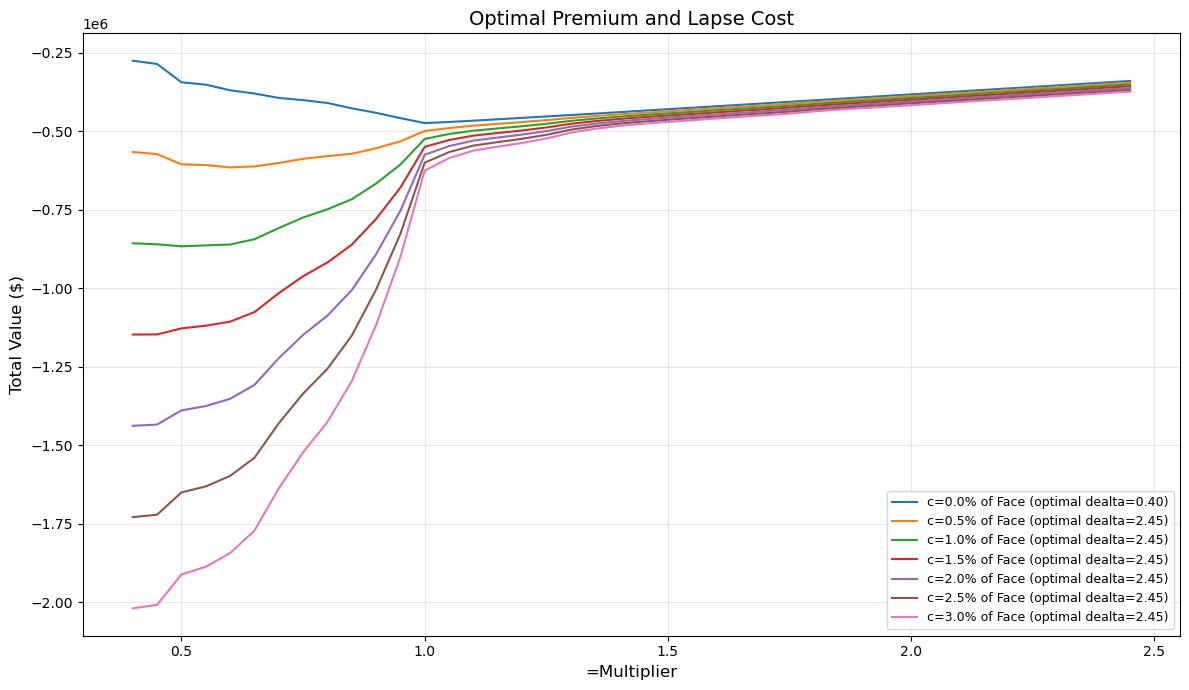

In [26]:
costs = [0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
deltas_grid = np.arange(0.4, 2.5, 0.05)

plt.figure(figsize=(12, 7))
for c in costs:
    pvs_c = [portfolio_pv(d, active, xgb_model, feature_cols, lapse_cost_pct=c) 
             for d in deltas_grid]
    best = deltas_grid[np.argmax(pvs_c)]
    plt.plot(deltas_grid, pvs_c, label=f'c={c:.1%} of Face (optimal dealta={best:.2f})')

plt.xlabel('=Multiplier', fontsize=12)
plt.ylabel('Total Value ($)', fontsize=12)
plt.title('Optimal Premium and Lapse Cost', fontsize=14)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
def find_optimal_delta(row, model, feature_cols, deltas=np.arange(0.5, 2.5, 0.05)):
    """
    Instead of apply multiplier across the entire portfolio, we optimize single policyholders' premium price
    
    """
    best_delta, best_pv = 1.0, -np.inf
    for d in deltas:
        temp = row.copy()
        temp['Annual_Premium'] = row['Annual_Premium'] * d
        temp['Premium_ratio'] = row['Premium_ratio'] * d
        temp_df = pd.DataFrame([temp[feature_cols]])
        p_lapse = model.predict_proba(temp_df)[:, 1][0]
        
        pv=0
        in_force = 1
        for t in range(1, int(row['Remaining_Term']) + 1):
            net= temp['Annual_Premium'] * in_force - row['Face_Amount'] * row['Mortality_Rate'] * in_force - row['Face_Amount'] * 0.02 * in_force * p_lapse
            pv += net / (1.05 ** t)
            in_force *= (1 - row['Mortality_Rate']) * (1 - p_lapse)
        if pv > best_pv:
            best_pv, best_delta = pv, d
    return best_delta, best_pv

results = active.apply(
    lambda row: find_optimal_delta(row, xgb_model, feature_cols), axis=1
)

active['optimal_delta'] = [r[0] for r in results]
active['optimal_PV'] = [r[1] for r in results]

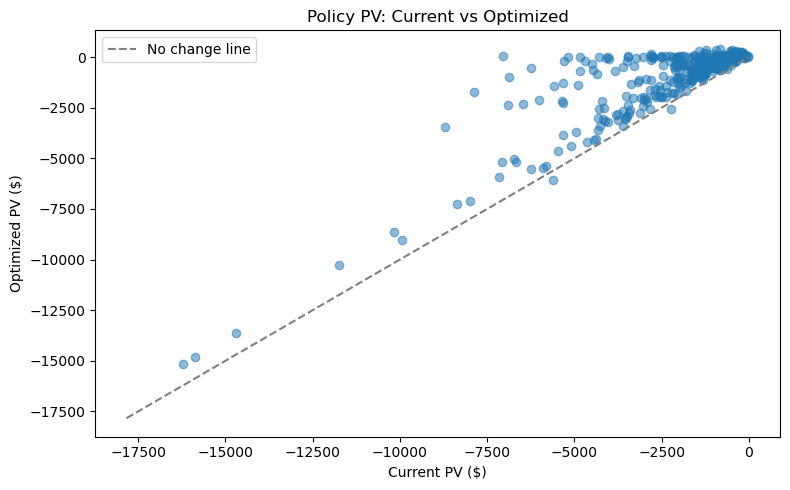

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(active['PV_xgboost'], active['optimal_PV'], alpha=0.5)
lims = [active['PV_xgboost'].min() * 1.1, 0]
plt.plot(lims, lims, '--', color='gray', label='No change line')
plt.xlabel('Current PV ($)')
plt.ylabel('Optimized PV ($)')
plt.title('Policy PV: Current vs Optimized')
plt.legend()
plt.tight_layout()
plt.show()

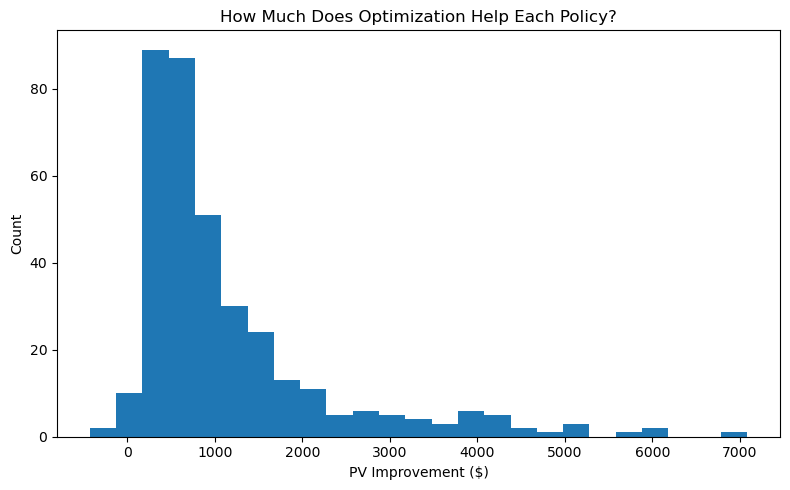

In [30]:
active['pv_improvement'] = active['optimal_PV'] - active['PV_xgboost']

plt.figure(figsize=(8, 5))
plt.hist(active['pv_improvement'], bins=25)
plt.xlabel('PV Improvement ($)')
plt.ylabel('Count')
plt.title('How Much Does Optimization Help Each Policy?')
plt.tight_layout()
plt.show()